In [5]:
import os
import re
import pandas as pd

BASE_DIR = "/Users/rohanbabbar/Documents/Final Year/cwe/C/testcases"
OUTPUT_CSV = "juliet_cwe_dataset.csv"

def clean_code(code):
    code = re.sub(r"/\*.*?\*/", "", code, flags=re.DOTALL)  # remove /* */
    code = re.sub(r"//.*", "", code)                       # remove //
    code = re.sub(r"\s+", " ", code)
    return code.strip()

# FIXED: correctly extract CWE from folder names
def extract_cwe_from_path(path):
    parts = path.split(os.sep)
    for part in parts:
        if part.startswith("CWE"):
            # Extract up to the first "_"
            match = re.match(r"(CWE\d+)", part)
            if match:
                return match.group(1)
    return None

# FIXED: detect good/bad correctly even in functions like goodG2B, bad()
def identify_good_bad(code):
    bad_fn = re.findall(r"CWE\d+_.*?bad[A-Za-z0-9_]*", code)
    good_fn = re.findall(r"CWE\d+_.*?good[A-Za-z0-9_]*", code)

    labels = []
    if bad_fn:
        labels.append("bad")
    if good_fn:
        labels.append("good")

    return labels if labels else ["unknown"]

data = []

print("\n🔍 Scanning Juliet dataset...\n")

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.endswith((".c", ".cpp", ".h")):  # FIXED
            full_path = os.path.join(root, file)

            try:
                raw_code = open(full_path, "r", encoding="latin-1").read()
            except:
                continue

            cwe = extract_cwe_from_path(full_path)
            if not cwe:
                continue

            labels = identify_good_bad(raw_code)
            clean = clean_code(raw_code)

            for lb in labels:
                if lb == "unknown":
                    continue
                data.append({
                    "file_path": full_path,
                    "filename": file,
                    "cwe": cwe,
                    "label": lb,
                    "code_raw": raw_code,
                    "code_clean": clean
                })

df = pd.DataFrame(data)
df = df.reset_index(drop=True)

# Add numeric labels
df["cwe_index"] = df["cwe"].astype("category").cat.codes
df["label_id"] = df["label"].map({"good": 0, "bad": 1})

df.to_csv(OUTPUT_CSV, index=False)

print("\n=============================================")
print("✅ Extraction Completed Successfully!")
print("📦 Samples:", len(df))
print("🔢 Unique CWEs:", df["cwe"].nunique())
print("💾 Saved to:", OUTPUT_CSV)
print("=============================================\n")


🔍 Scanning Juliet dataset...


✅ Extraction Completed Successfully!
📦 Samples: 179839
🔢 Unique CWEs: 118
💾 Saved to: juliet_cwe_dataset.csv



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed dataset
old_df = pd.read_csv("/Users/rohanbabbar/Documents/Final Year/cwe/Archive/juliet_cwe_dataset.csv")

print("📦 Dataset Loaded!")
print(df.shape)
df.head()

📦 Dataset Loaded!
(179839, 8)


,file_path,filename,cwe,label,code_raw,code_clean,cwe_index,label_id
0,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,CWE226_Sensitive_Information_Uncleared_Before_...,CWE226,bad,/* TEMPLATE GENERATED TESTCASE FILE\nFilename:...,"#include ""std_testcase.h"" #include <wchar.h> #...",19,1
1,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,CWE226_Sensitive_Information_Uncleared_Before_...,CWE226,good,/* TEMPLATE GENERATED TESTCASE FILE\nFilename:...,"#include ""std_testcase.h"" #include <wchar.h> #...",19,0
2,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,CWE226_Sensitive_Information_Uncleared_Before_...,CWE226,bad,/* TEMPLATE GENERATED TESTCASE FILE\nFilename:...,"#include ""std_testcase.h"" #include <wchar.h> #...",19,1
3,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,CWE226_Sensitive_Information_Uncleared_Before_...,CWE226,good,/* TEMPLATE GENERATED TESTCASE FILE\nFilename:...,"#include ""std_testcase.h"" #include <wchar.h> #...",19,0
4,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,CWE226_Sensitive_Information_Uncleared_Before_...,CWE226,bad,/* TEMPLATE GENERATED TESTCASE FILE\nFilename:...,"#include ""std_testcase.h"" #include <wchar.h> #...",19,1


In [12]:
import pandas as pd

# Load full dataset
df = pd.read_csv("juliet_cwe_dataset.csv")

print("Full dataset size:", len(df))

def stratified_sample(df, frac=0.01, min_samples=5):
    samples = []
    for cwe, group in df.groupby("cwe"):
        n = max(int(len(group) * frac), min_samples)
        samples.append(group.sample(n=min(n, len(group)), random_state=42))
    return pd.concat(samples).reset_index(drop=True)

sample_df = stratified_sample(df, frac=0.01, min_samples=5)
print("CWEs preserved:", sample_df["cwe"].nunique())
print("Sample size:", len(sample_df))
print("Unique CWEs:", sample_df["cwe"].nunique())

# Check distribution similarity
print("\nOriginal distribution (top 10):")
print(df["cwe"].value_counts(normalize=True).head(10))

print("\nSample distribution (top 10):")
print(sample_df["cwe"].value_counts(normalize=True).head(10))

# Save sample dataset
sample_df.to_csv("juliet_cwe_sample(1%).csv", index=False)
print("\n📄 Saved 1% sample as juliet_cwe_sample(1%).csv")

Full dataset size: 179839
CWEs preserved: 118
Sample size: 2065
Unique CWEs: 118

Original distribution (top 10):
cwe
CWE122    0.090714
CWE121    0.083063
CWE78     0.082540
CWE190    0.068294
CWE134    0.050879
CWE191    0.050478
CWE762    0.048232
CWE590    0.036699
CWE127    0.033107
CWE124    0.033107
Name: proportion, dtype: float64

Sample distribution (top 10):
cwe
CWE122    0.078935
CWE121    0.072155
CWE78     0.071671
CWE190    0.059080
CWE134    0.044068
CWE191    0.043584
CWE762    0.041646
CWE590    0.031961
CWE124    0.028571
CWE127    0.028571
Name: proportion, dtype: float64

📄 Saved 1% sample as juliet_cwe_sample(1%).csv


In [15]:
df = pd.read_csv("juliet_cwe_dataset.csv")
print("Total CWEs in full dataset:", df["cwe"].nunique())

sample_df = pd.read_csv("juliet_cwe_sample(1%).csv")
print("CWEs in 1% sample:", sample_df["cwe"].nunique())

rare_counts = (df["cwe"].value_counts().sort_values().head(30))
print("\n30 smallest CWE folders:\n", rare_counts)

Total CWEs in full dataset: 118
CWEs in 1% sample: 118

30 smallest CWE folders:
 cwe
CWE440     8
CWE674    10
CWE561    10
CWE500    10
CWE562    12
CWE835    18
CWE571    38
CWE570    38
CWE780    40
CWE615    40
CWE222    40
CWE223    40
CWE785    40
CWE620    40
CWE247    40
CWE338    40
CWE364    42
CWE526    42
CWE196    42
CWE480    42
CWE479    42
CWE667    42
CWE481    42
CWE484    42
CWE587    42
CWE482    42
CWE605    42
CWE832    42
CWE688    42
CWE676    42
Name: count, dtype: int64


In [16]:
print("🔍 Columns:")
print(df.columns)

print("\n📊 Data Types:")
print(df.dtypes)

🔍 Columns:
Index(['file_path', 'filename', 'cwe', 'label', 'code_raw', 'code_clean',
       'cwe_index', 'label_id'],
      dtype='object')

📊 Data Types:
file_path     object
filename      object
cwe           object
label         object
code_raw      object
code_clean    object
cwe_index      int64
label_id       int64
dtype: object


In [17]:
print(f"🔢 Total Samples: {len(df)}")
print(f"🧩 Unique CWE Types: {df['cwe'].nunique()}")

df['cwe'].value_counts().head(15)

🔢 Total Samples: 179839
🧩 Unique CWE Types: 118


cwe
CWE122    16314
CWE121    14938
CWE78     14844
CWE190    12282
CWE134     9150
CWE191     9078
CWE762     8674
CWE590     6600
CWE127     5954
CWE124     5954
CWE23      5724
CWE36      5724
CWE401     4598
CWE126     4156
CWE195     3564
Name: count, dtype: int64

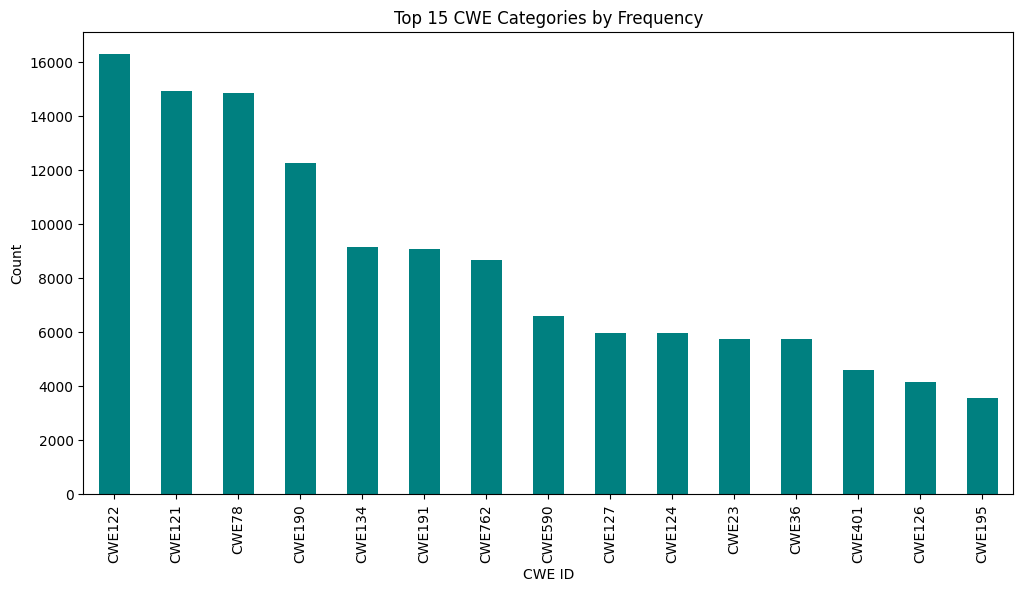

In [18]:
plt.figure(figsize=(12,6))
df['cwe'].value_counts().head(15).plot(kind='bar', color='teal')
plt.title("Top 15 CWE Categories by Frequency")
plt.xlabel("CWE ID")
plt.ylabel("Count")
plt.show()

label
good    90646
bad     89193
Name: count, dtype: int64


/var/folders/_t/79359yk13vl8dqw3v2p08c9c0000gn/T/ipykernel_65395/1967353216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='coolwarm')


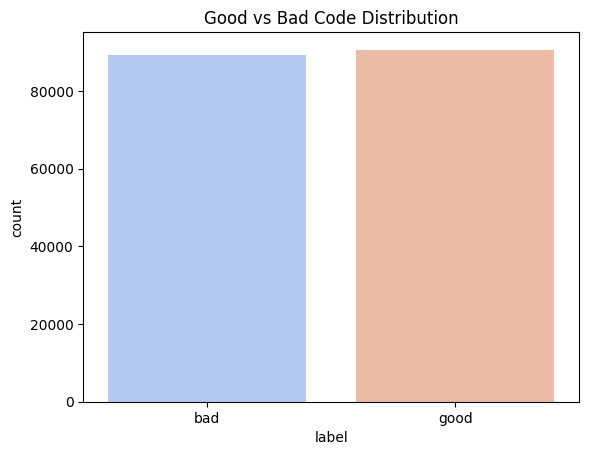

In [19]:
print(df['label'].value_counts())

sns.countplot(data=df, x='label', palette='coolwarm')
plt.title("Good vs Bad Code Distribution")
plt.show()

In [20]:
sample = df.sample(1).iloc[0]

print("🔵 RAW CODE SAMPLE:\n")
print(sample['code_raw'][:500])  # print first 500 chars

print("\n🟢 CLEANED CODE SAMPLE:\n")
print(sample['code_clean'][:500])

🔵 RAW CODE SAMPLE:

/* TEMPLATE GENERATED TESTCASE FILE
Filename: CWE23_Relative_Path_Traversal__char_environment_open_02.cpp
Label Definition File: CWE23_Relative_Path_Traversal.label.xml
Template File: sources-sink-02.tmpl.cpp
*/
/*
 * @description
 * CWE: 23 Relative Path Traversal
 * BadSource: environment Read input from an environment variable
 * GoodSource: Use a fixed file name
 * Sink: open
 *    BadSink : Open the file named in data using open()
 * Flow Variant: 02 Control flow: if(1) and if(0)
 *
 * */



🟢 CLEANED CODE SAMPLE:

#include "std_testcase.h" #ifdef _WIN32 #define BASEPATH "c:\\temp\\" #else #include <wchar.h> #define BASEPATH "/tmp/" #endif #define ENV_VARIABLE "ADD" #ifdef _WIN32 #define GETENV getenv #else #define GETENV getenv #endif #ifdef _WIN32 #define OPEN _open #define CLOSE _close #else #include <unistd.h> #define OPEN open #define CLOSE close #endif namespace CWE23_Relative_Path_Traversal__char_environment_open_02 { #ifndef OMITBAD void bad() { char * 

In [21]:
df['code_len'] = df['code_clean'].apply(len)

df['code_len'].describe()

count    179839.000000
mean       2033.556514
std        7978.710767
min         203.000000
25%         971.000000
50%        1331.000000
75%        1808.000000
max      292370.000000
Name: code_len, dtype: float64

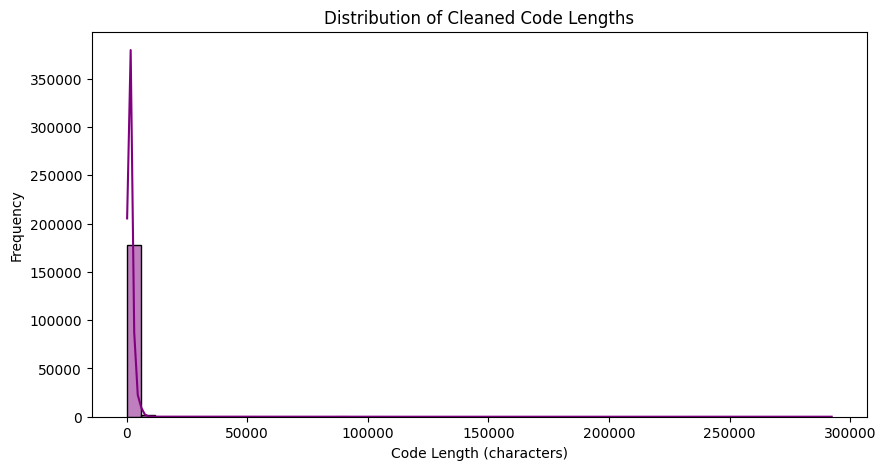

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['code_len'], bins=50, kde=True, color='purple')
plt.title("Distribution of Cleaned Code Lengths")
plt.xlabel("Code Length (characters)")
plt.ylabel("Frequency")
plt.show()

In [23]:
sample_groups = df.groupby("cwe").head(1)[["cwe","file_path","label","code_clean"]]
sample_groups.head(10)

,cwe,file_path,label,code_clean
0,CWE226,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include <wchar.h> #..."
148,CWE338,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include <windows.h>..."
188,CWE761,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include <wchar.h> #..."
1970,CWE364,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include <signal.h> ..."
2012,CWE398,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #ifndef OMITBAD void..."
2380,CWE190,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #ifndef OMITBAD void..."
14662,CWE506,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include <windows.h>..."
14915,CWE666,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include <wchar.h> #..."
15101,CWE667,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,bad,"#include ""std_testcase.h"" #include ""std_thread..."
15143,CWE672,/Users/rohanbabbar/Documents/Final Year/cwe/C/...,good,"#ifndef OMITGOOD #include ""std_testcase.h"" #in..."


In [24]:
print("=============================================")
print("📌 Juliet Dataset: EDA Summary")
print("=============================================")
print(f"Total Samples: {len(df)}")
print(f"Unique CWE Types: {df['cwe'].nunique()}")
print(f"Good/Bad Distribution:\n{df['label'].value_counts()}")
print("=============================================")

📌 Juliet Dataset: EDA Summary
Total Samples: 179839
Unique CWE Types: 118
Good/Bad Distribution:
label
good    90646
bad     89193
Name: count, dtype: int64
